# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [8]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Saulo Francisco Michell Romero Diaz"            # Tu nombre completo
MATRICULA = "82187"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Saulo Francisco Michell Romero Diaz
Matrícula: 82187
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\5to Semestre\BigData\Examen\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}



config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [10]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [11]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [12]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [13]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [14]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [15]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*(Consolo ver los primero 25 datos me doy cuenta del porque son esto valores nulos en en las filas 23 y 24 aparece la entidad "Africa (FAO)" y su código (code) es NaN esas filas representan regiones, continentes o agrupaciones y no a países individuales por otro lado los países reales como Afghanistan sí tienen un código ISO de 3 letras)*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [22]:
# Pregunta 1
# Tu codigo aqui
col_filtro = config['filtro_paises']

# Quitar los nulos
df_paises = df.dropna(subset=[col_filtro])

# 2. regiones globales 
df_paises = df_paises[~df_paises[col_filtro].str.startswith('OWID')]

valores_agrupados = df_paises.groupby('entity')['valor'].mean()

cantidad_paises = df_paises['entity'].nunique()
print(f"Hay {cantidad_paises} países\n")

print("--- 10 Países con MAYOR valor ---")
print(valores_agrupados.nlargest(10))

print("\n--- 10 Países con MENOR valor ---")
print(valores_agrupados.nsmallest(10))

Hay 139 países

--- 10 Países con MAYOR valor ---
entity
India                           1.875739e+08
China                           8.724444e+07
Pakistan                        3.121304e+07
Indonesia                       2.811739e+07
Democratic Republic of Congo    2.382174e+07
Ethiopia                        2.264783e+07
Bangladesh                      2.238261e+07
Nigeria                         2.161739e+07
Tanzania                        1.180000e+07
Philippines                     1.175652e+07
Name: valor, dtype: float64

--- 10 Países con MENOR valor ---
entity
Barbados                  100000.0
Belize                    100000.0
Bosnia and Herzegovina    100000.0
Cape Verde                100000.0
Comoros                   100000.0
Cyprus                    100000.0
Dominica                  100000.0
Estonia                   100000.0
Fiji                      100000.0
French Polynesia          100000.0
Name: valor, dtype: float64


**Interpretación:**

*(Hay 139 paises distintos, pero existe un codigo que nos marca World porloque se debe eliminar para pasar de 140 a 139)*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [29]:
# Pregunta 2
# Tu codigo aqui
paises = ['Mexico', 'China']
df_mis2paises = df_paises[df_paises['entity'].isin(paises)]

años_mexico = set(df_mis2paises[df_mis2paises['entity'] == 'Mexico']['year'])
años_china = set(df_mis2paises[df_mis2paises['entity'] == 'China']['year'])

mismos_años = años_mexico.intersection(años_china)

df_MXCH = df_mis2paises[df_mis2paises['year'].isin(mismos_años)]
df_MXCH

,entity,code,year,valor
632,China,CHN,2001,127300000.0
633,China,CHN,2002,120200000.0
634,China,CHN,2003,111300000.0
635,China,CHN,2004,101500000.0
636,China,CHN,2005,90600000.0
637,China,CHN,2006,78800000.0
638,China,CHN,2007,65300000.0
639,China,CHN,2008,51700000.0
640,China,CHN,2009,38500000.0
1964,Mexico,MEX,2001,2800000.0


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [31]:
# Pregunta 3
# Tu codigo aqui
mis_5_paises = ['Mexico', 'Germany', 'Japan', 'Nigeria', 'Australia']

df_5 = df_paises[df_paises['entity'].isin(mis_5_paises)]

año_mas_reciente = df_5['year'].max()

df_reciente = df_5[df_5['year'] == año_mas_reciente]

idx_max = df_reciente['valor'].idxmax()
idx_min = df_reciente['valor'].idxmin()

pais_max = df_reciente.loc[idx_max, 'entity']
valor_max = df_reciente.loc[idx_max, 'valor']

pais_min = df_reciente.loc[idx_min, 'entity']
valor_min = df_reciente.loc[idx_min, 'valor']

diferencia = valor_max - valor_min

print(f"Año analizado: {año_mas_reciente}\n")
print("--- Valores de los 5 países ---")
print(df_reciente[['entity', 'valor']])

print(f"\nValor MÁS ALTO: {pais_max} ({valor_max})")
print(f"Valor MÁS BAJO: {pais_min} ({valor_min})")
print(f"Diferencia entre ambos: {diferencia}")

Año analizado: 2023

--- Valores de los 5 países ---
       entity       valor
1986   Mexico   3500000.0
2260  Nigeria  45400000.0

Valor MÁS ALTO: Nigeria (45400000.0)
Valor MÁS BAJO: Mexico (3500000.0)
Diferencia entre ambos: 41900000.0


**Interpretación:**

*Esta enorme brecha de mas de 40 millones me hace pensar que el fenómeno medido depende fuertemente de contextos demográficos, geográficos o económicos muy distintos entre ambas regiones lo cual evidencia una crisis alimentaria significativamente más severa frente a Latinoamérica*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [ ]:
# Pregunta 4
# Tu codigo aqui
latam = ['Mexico', 'Colombia', 'Argentina']
asia = ['China', 'Japan', 'Vietnam'] # Si Vietnam no está, puedes cambiarlo por 'South Korea' o 'India'

df_grupos = df_paises[df_paises['entity'].isin(latam + asia)]

año_reciente = df_grupos['year'].max()

df_reciente = df_grupos[df_grupos['year'] == año_reciente]

promedio_latam = df_reciente[df_reciente['entity'].isin(latam)]['valor'].mean()
promedio_asia = df_reciente[df_reciente['entity'].isin(asia)]['valor'].mean()

print(f"--- Año analizado: {año_reciente} ---")
print(f"Latinoamérica: {promedio_latam}")
print(f"Asia: {promedio_asia}")

--- Año analizado: 2023 ---
Latinoamérica: 2333333.3333333335
Asia: 5300000.0


**Interpretación:**

*En 2023, el bloque asiático presenta en promedio más del doble de personas con desnutrición que el latinoamericano pero cabe recalcar que el contienete asiatico tiene una alta densidad poblacional y una gran masa territorial que dificulta seguramente el transporte de alimentos el ejemplo claro es china por otro lado paises como japon pues supongo que es por cuestiones sociales *

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [34]:
# Pregunta 5
# Tu codigo aqui
df_pais = df_paises[df_paises['entity'] == 'Nigeria'].sort_values('year').reset_index(drop=True)

fila_max = df_pais.loc[df_pais['valor'].idxmax()]
fila_min = df_pais.loc[df_pais['valor'].idxmin()]

año_max, val_max = int(fila_max['year']), fila_max['valor']
año_min, val_min = int(fila_min['year']), fila_min['valor']

primer_año, primer_val = int(df_pais.iloc[0]['year']), df_pais.iloc[0]['valor']
ultimo_año, ultimo_val = int(df_pais.iloc[-1]['year']), df_pais.iloc[-1]['valor']
cambio_neto = ultimo_val - primer_val

print(f"Rango de años: {primer_año} - {ultimo_año}")
print(f"Valor MÁXIMO: {val_max:,.0f} (Año: {año_max})")
print(f"Valor MÍNIMO: {val_min:,.0f} (Año: {año_min})")
print(f"Diferencia neta ({primer_año} a {ultimo_año}): {cambio_neto:,.0f}")

Rango de años: 2001 - 2023
Valor MÁXIMO: 45,400,000 (Año: 2023)
Valor MÍNIMO: 11,300,000 (Año: 2001)
Diferencia neta (2001 a 2023): 34,100,000


**Interpretación:**

La desnutrición en Nigeria muestra una clara tendencia creciente, alcanzando su mínimo en 2001 y su pico histórico en 2023

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [35]:
# Pregunta 6
# Tu codigo aqui

df_mex = df_paises[df_paises['entity'] == 'Mexico'].sort_values('year').reset_index(drop=True)

año_inicial = int(df_mex.iloc[0]['year'])
val_inicial = df_mex.iloc[0]['valor']

año_final = int(df_mex.iloc[-1]['year'])
val_final = df_mex.iloc[-1]['valor']

cambio_pct = ((val_final - val_inicial) / val_inicial) * 100

print(f"Año inicial ({año_inicial}): {val_inicial:,.0f}")
print(f"Año final ({año_final}): {val_final:,.0f}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")

Año inicial (2001): 2,800,000
Año final (2023): 3,500,000
Cambio porcentual: 25.00%


**Interpretación:**

Recuerdo que por esas fechas fue el covid y gracias que la gente estaba mucho en casa pues crecio la población y los alimentos subieron de precio, aun que un incremento relativo del 25% sigue siendo una cifra significativa

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [37]:
# Pregunta 7
# Tu codigo aqui
año_reciente = df_paises['year'].max()

valores_array = df_paises.loc[df_paises['year'] == año_reciente, 'valor'].dropna().to_numpy()

media = np.mean(valores_array)
mediana = np.median(valores_array)
desviacion_std = np.std(valores_array, ddof=1)  # ddof=1 para desviación estándar muestral segun chat haha

print(f"--- Estadísticas Año {año_reciente} (NumPy) ---")
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación Estándar: {desviacion_std:,.2f}")

--- Estadísticas Año 2023 (NumPy) ---
Media: 5,884,761.90
Mediana: 1,600,000.00
Desviación Estándar: 18,237,428.66


**Interpretación:**

La media (5.88M) es casi cuatro veces superior a la mediana (1.60M), evidenciando una distribución fuertemente asimétrica hacia la derecha. La enorme desviación estándar (18.24M) refleja una altísima dispersión y desigualdad global, provocada por unos pocos países atípicos con poblaciones gigantescas y cifras críticas (como India o Nigeria) que inflan el promedio general.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

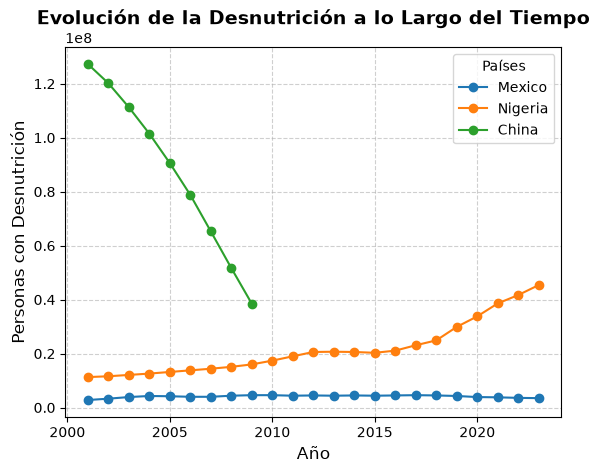

In [ ]:
# Pregunta 8
# Tu codigo aqui
paises_grafica = ['Mexico', 'Nigeria', 'China']

for pais in paises_grafica:
    datos_pais = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(datos_pais['year'], datos_pais['valor'], marker='o', label=pais)


plt.title('Evolución de la Desnutrición a lo Largo del Tiempo', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Personas con Desnutrición', fontsize=12)
plt.legend(title='Países')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

**Interpretación:**

La gráfica revela tres comportamientos drásticamente distintos: China logró una reducción masiva y acelerada de la desnutrición en la primera década de los 2000, mientras que Nigeria muestra una tendencia alarmantemente creciente que se dispara a partir de 2015. Por su parte, México se mantiene estable a lo largo de todo el periodo, con cifras absolutas mucho menores y sin picos drásticos en esta escala visual.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

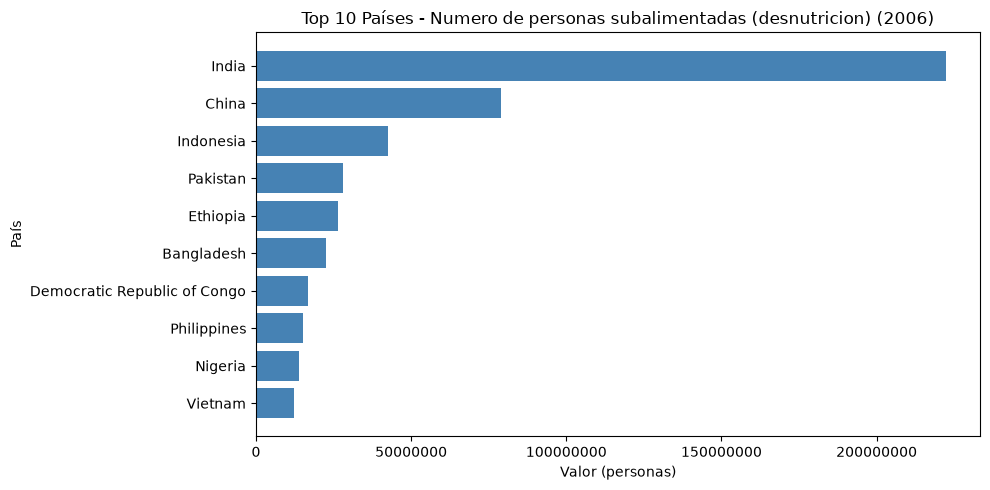

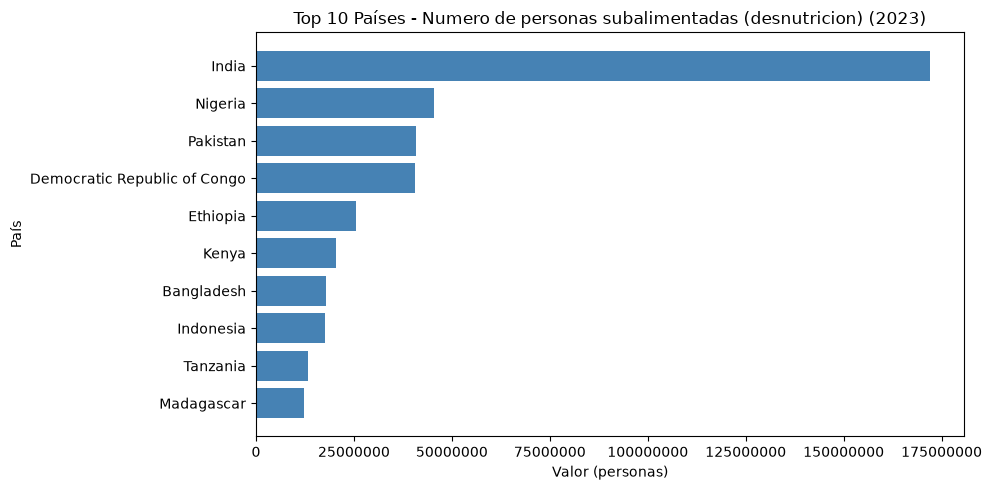

In [44]:
# Pregunta 9
# Tu codigo aqui
# Filtro robusto de países reales
col_filtro = config["filtro_paises"]
df_paises = df[df[col_filtro].notnull() & ~df[col_filtro].str.startswith('OWID')]

# Generar gráfica para 2006 y 2023
for anio_consultado in [2006, 2023]:
    top = (
        df_paises[df_paises['year'] == anio_consultado]
        .sort_values('valor', ascending=False)
        .head(10)
    )
    
    plt.figure(figsize=(10, 5))
    plt.barh(top['entity'], top['valor'], color='steelblue')
    
    plt.xlabel(f"Valor ({config.get('unidad', 'Personas')})")
    plt.ylabel("País")
    plt.title(f"Top 10 Países - {config.get('descripcion', 'Desnutrición')} ({anio_consultado})")
    
    plt.gca().invert_yaxis()
    plt.ticklabel_format(style='plain', axis='x')
    plt.tight_layout()
    plt.show()



**Interpretación:**

En 2006 el top estaba dominado por naciones asiáticas (China, Indonesia, Vietnam). Para 2023, China y Vietnam salieron del ranking, mientras que países africano tomaron esos puestos, pero India se mantuvo en el primer lugar en ambos periodos; aunque redujo su cifra absoluta de más de 220 millones a unos 170 millones

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Al trabajar con este dataset aprendí que la desnutrición global presenta una fuerte asimetría y un desplazamiento geográfico marcado: mientras identifiqué que naciones como China redujeron drásticamente sus cifras y México se mantuvo relativamente estable, países de África Subsahariana como Nigeria tuvieron incrementos críticos entre 2001 y 2023.

Como principal limitación, detecté que manejar valores absolutos sin normalizar por población sesga el análisis hacia países masivos como India, con más tiempo, cruzaría estos datos con censos poblacionales para obtener tasas per cápita reales y aplicaría modelos predictivos para proyectar tendencias futuras.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
